This is a redo of the original SomnniVue using a deep audio classifier with Tensorflow because the original tree thing didn't really work.

Improvements to make:
* Try CQT or Mel Spectrograms
* Try CNN-RNN hybrid
* Mess with layers more

# Install Dependencies

In [4]:
!pip install tensorflow tensorflow-io matplotlib

ERROR: Could not find a version that satisfies the requirement tensorflow-io (from versions: none)
ERROR: No matching distribution found for tensorflow-io


In [5]:
import os
from matplotlib import pyplot as plt
import tensorflow as tf
#import tensorflow_io as tfio

# import pandas as pd
# import numpy as np
# import seaborn as sns
from glob import glob
import librosa
# import librosa.display

from google.colab import drive

import random

# Load Data

In [6]:
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
SNORING_FILES = glob("/content/drive/My Drive/SomniVue Stuff/Snoring Dataset/1/*.wav")
NONSNORING_FILES_ALL = glob("/content/drive/My Drive/SomniVue Stuff/Env Noise Dataset/audio/audio/*.wav")
NONSNORING_FILES = random.sample(NONSNORING_FILES_ALL, len(SNORING_FILES))

In [8]:
## Read audio files from specified location, resample to 16kHz and make single channel, return in tensor form
def load_wav(filename):
  # file_contents = tf.io.read_file(filename)
  # wav, sample_rate = tf.audio.decode_wav(file_contents, desired_channels=1)
  # wav = tf.squeeze(wav, axis=-1)
  # sample_rate = tf.cast(sample_rate, dtype=tf.int64)
  # wav = tfio.audio.resample(wav, rate_in=sample_rate, rate_out=16000)
  if isinstance(filename, tf.Tensor):
    filename = filename.numpy().decode('utf-8')
  wav, sr = librosa.load(filename, sr=16000, mono=True)
  wav = tf.convert_to_tensor(wav, dtype=tf.float32)
  return wav


In [9]:
snore_wave = load_wav(SNORING_FILES[1])
nonsnore_wave = load_wav(NONSNORING_FILES[1])

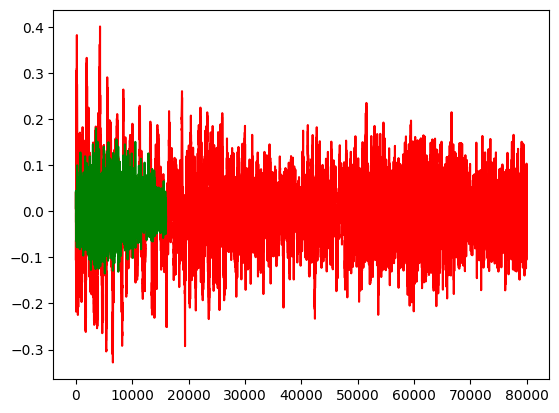

In [10]:
plt.plot(nonsnore_wave, color='red')
plt.plot(snore_wave, color='green')
plt.show()

In [11]:
snoring_tf_data = tf.data.Dataset.from_tensor_slices(SNORING_FILES)
nonsnoring_tf_data = tf.data.Dataset.from_tensor_slices(NONSNORING_FILES)

In [12]:
snoring_data = tf.data.Dataset.zip((snoring_tf_data, tf.data.Dataset.from_tensor_slices(tf.ones(len(snoring_tf_data)))))
nonsnoring_data = tf.data.Dataset.zip((nonsnoring_tf_data, tf.data.Dataset.from_tensor_slices(tf.zeros(len(nonsnoring_tf_data)))))

all_data = snoring_data.concatenate(nonsnoring_data)

# Data Exploration

In [13]:
## Calculate average snore length to define window later

lengths = [] # measured in number of samples
for file in SNORING_FILES:
  tensor_wave = load_wav(file)
  lengths.append(len(tensor_wave))

In [14]:
import statistics

mean = statistics.mean(lengths)
median = statistics.median(lengths)
minimum = sorted(lengths)[0]
maximum = sorted(lengths)[-1]

print(f"Mean: {mean}\nMedian: {median}\nMinimum: {minimum}\nMaximum: {maximum}")

Mean: 16000
Median: 16000.0
Minimum: 16000
Maximum: 16000


In [15]:
MEAN_LENGTH = int(sum(lengths) / len(lengths))

# Data Pre-processing

In [16]:
## Converts data into spectrograms
# Don't really need padding right now because all clips are same length but will keep for later

def preprocess(filename, label):
  # wav = load_wav(filename)
  wav = tf.py_function(load_wav, [filename], tf.float32)
  wav.set_shape([None]) # temp so that the training works; will not need this when get correct tensorflow version
  wav = wav[:MEAN_LENGTH]
  zero_padding = tf.zeros([MEAN_LENGTH] - tf.shape(wav), dtype=tf.float32)
  wav = tf.concat([zero_padding, wav], 0)
  spectrogram = tf.signal.stft(wav, frame_length=320, frame_step=32) # 90% overlap
  spectrogram = tf.abs(spectrogram)
  spectrogram = tf.expand_dims(spectrogram, axis=2) # fix size to match expected
  return spectrogram, label

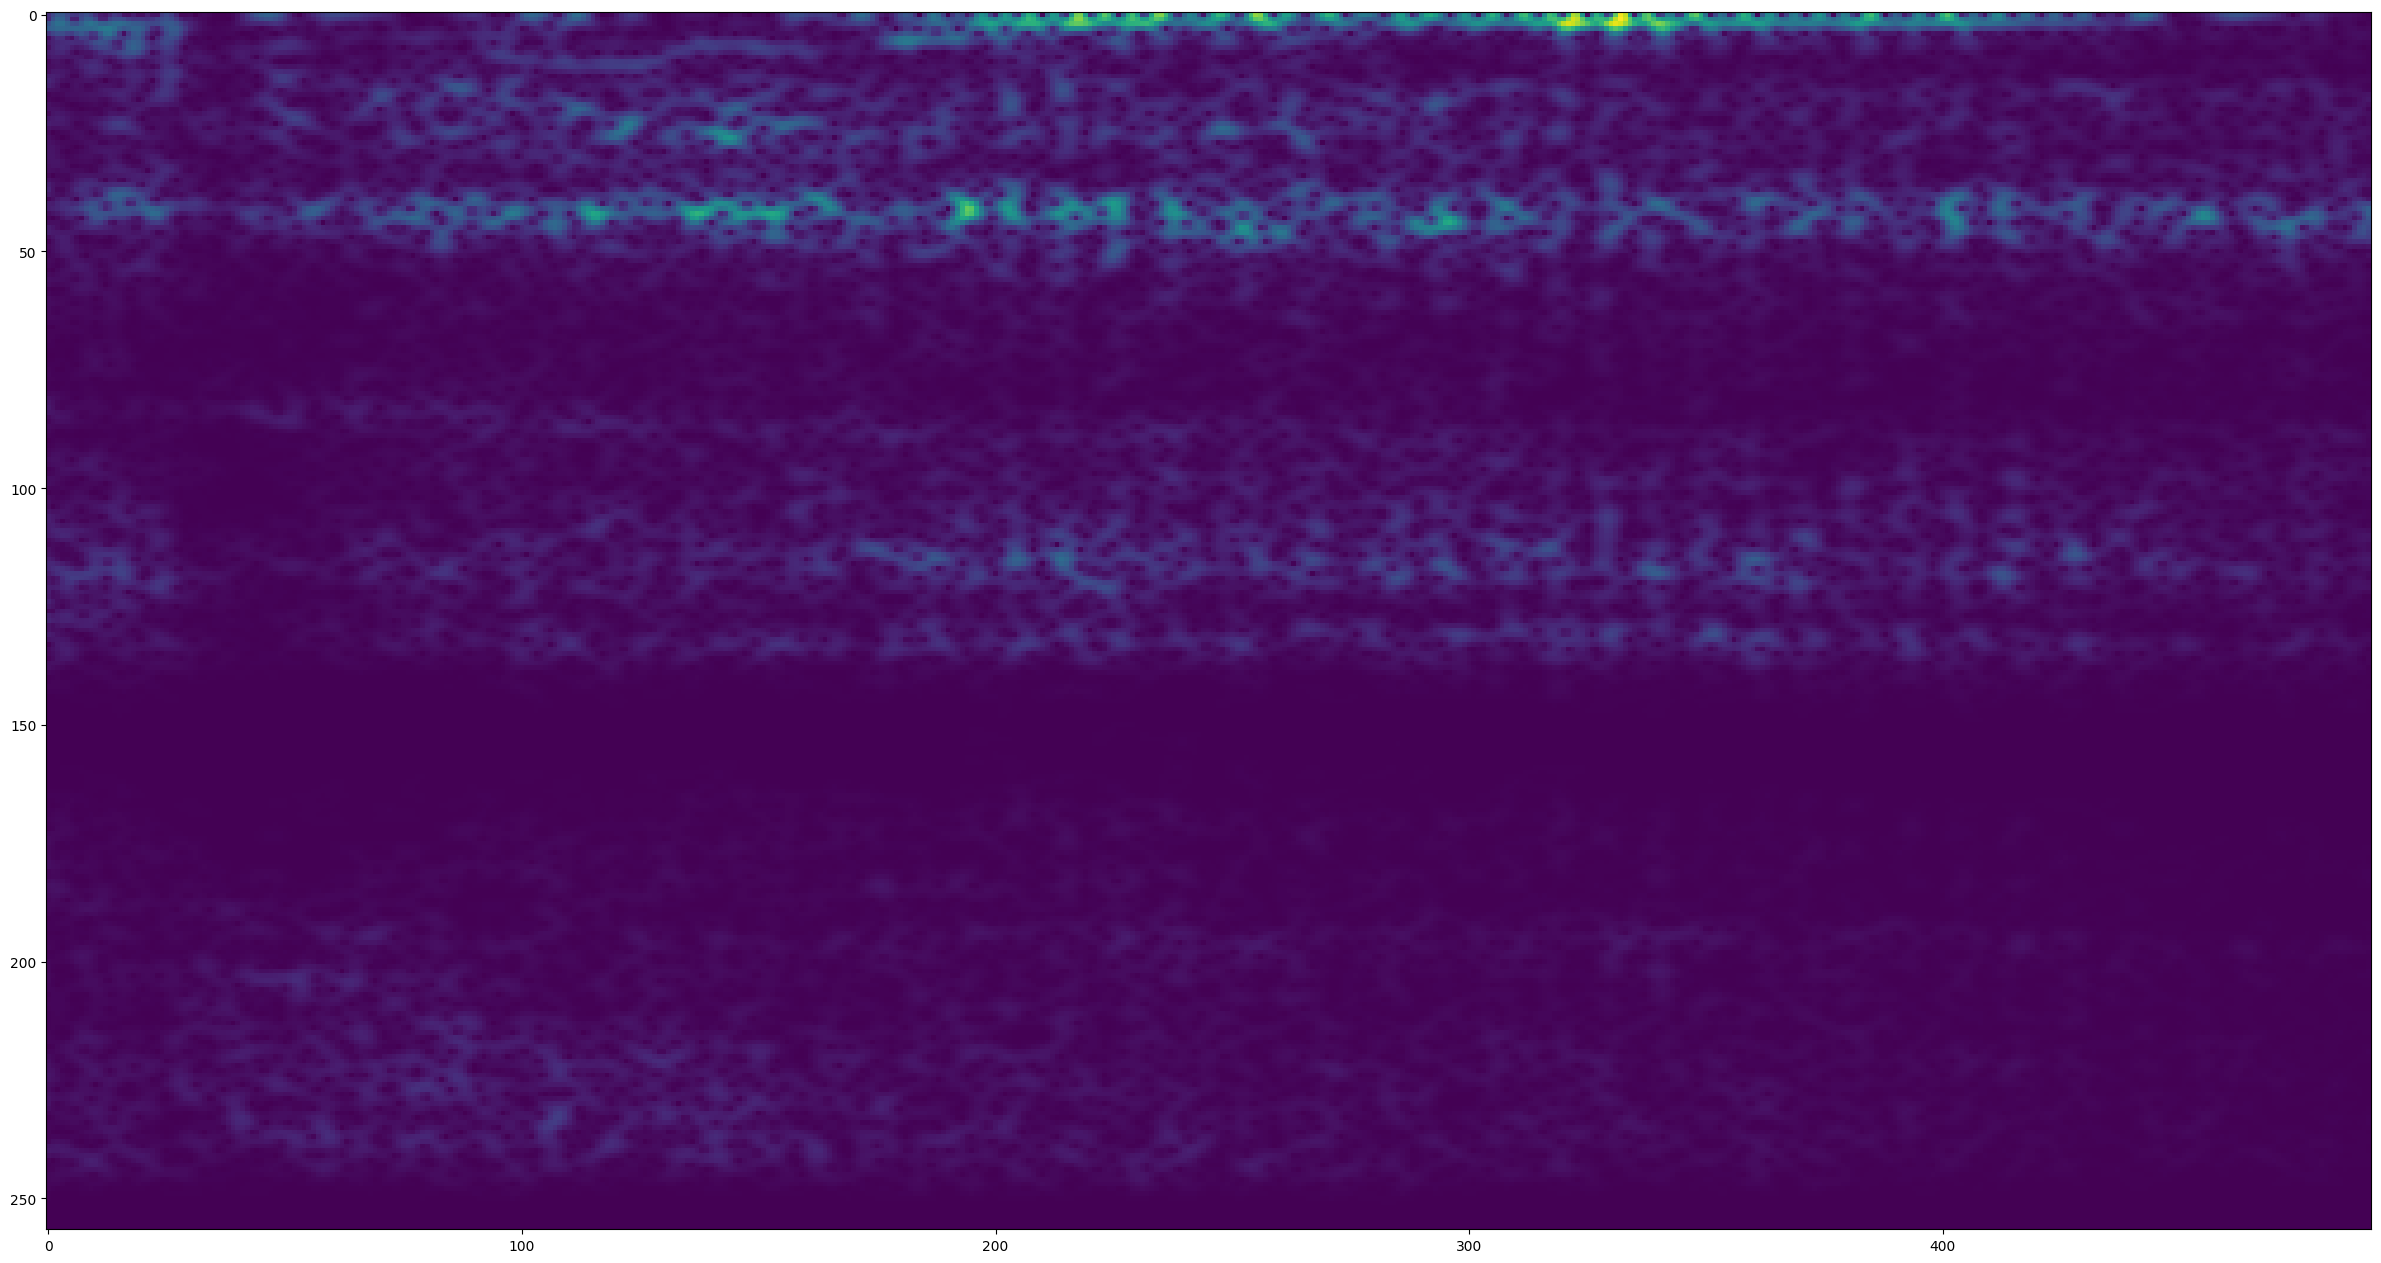

In [17]:
sample, label = snoring_data.shuffle(buffer_size=1000).as_numpy_iterator().next()
spectrogram, label = preprocess(sample, label)
#print(spectrogram)
plt.figure(figsize=(30,20))
plt.imshow(tf.transpose(spectrogram)[0])
plt.show()

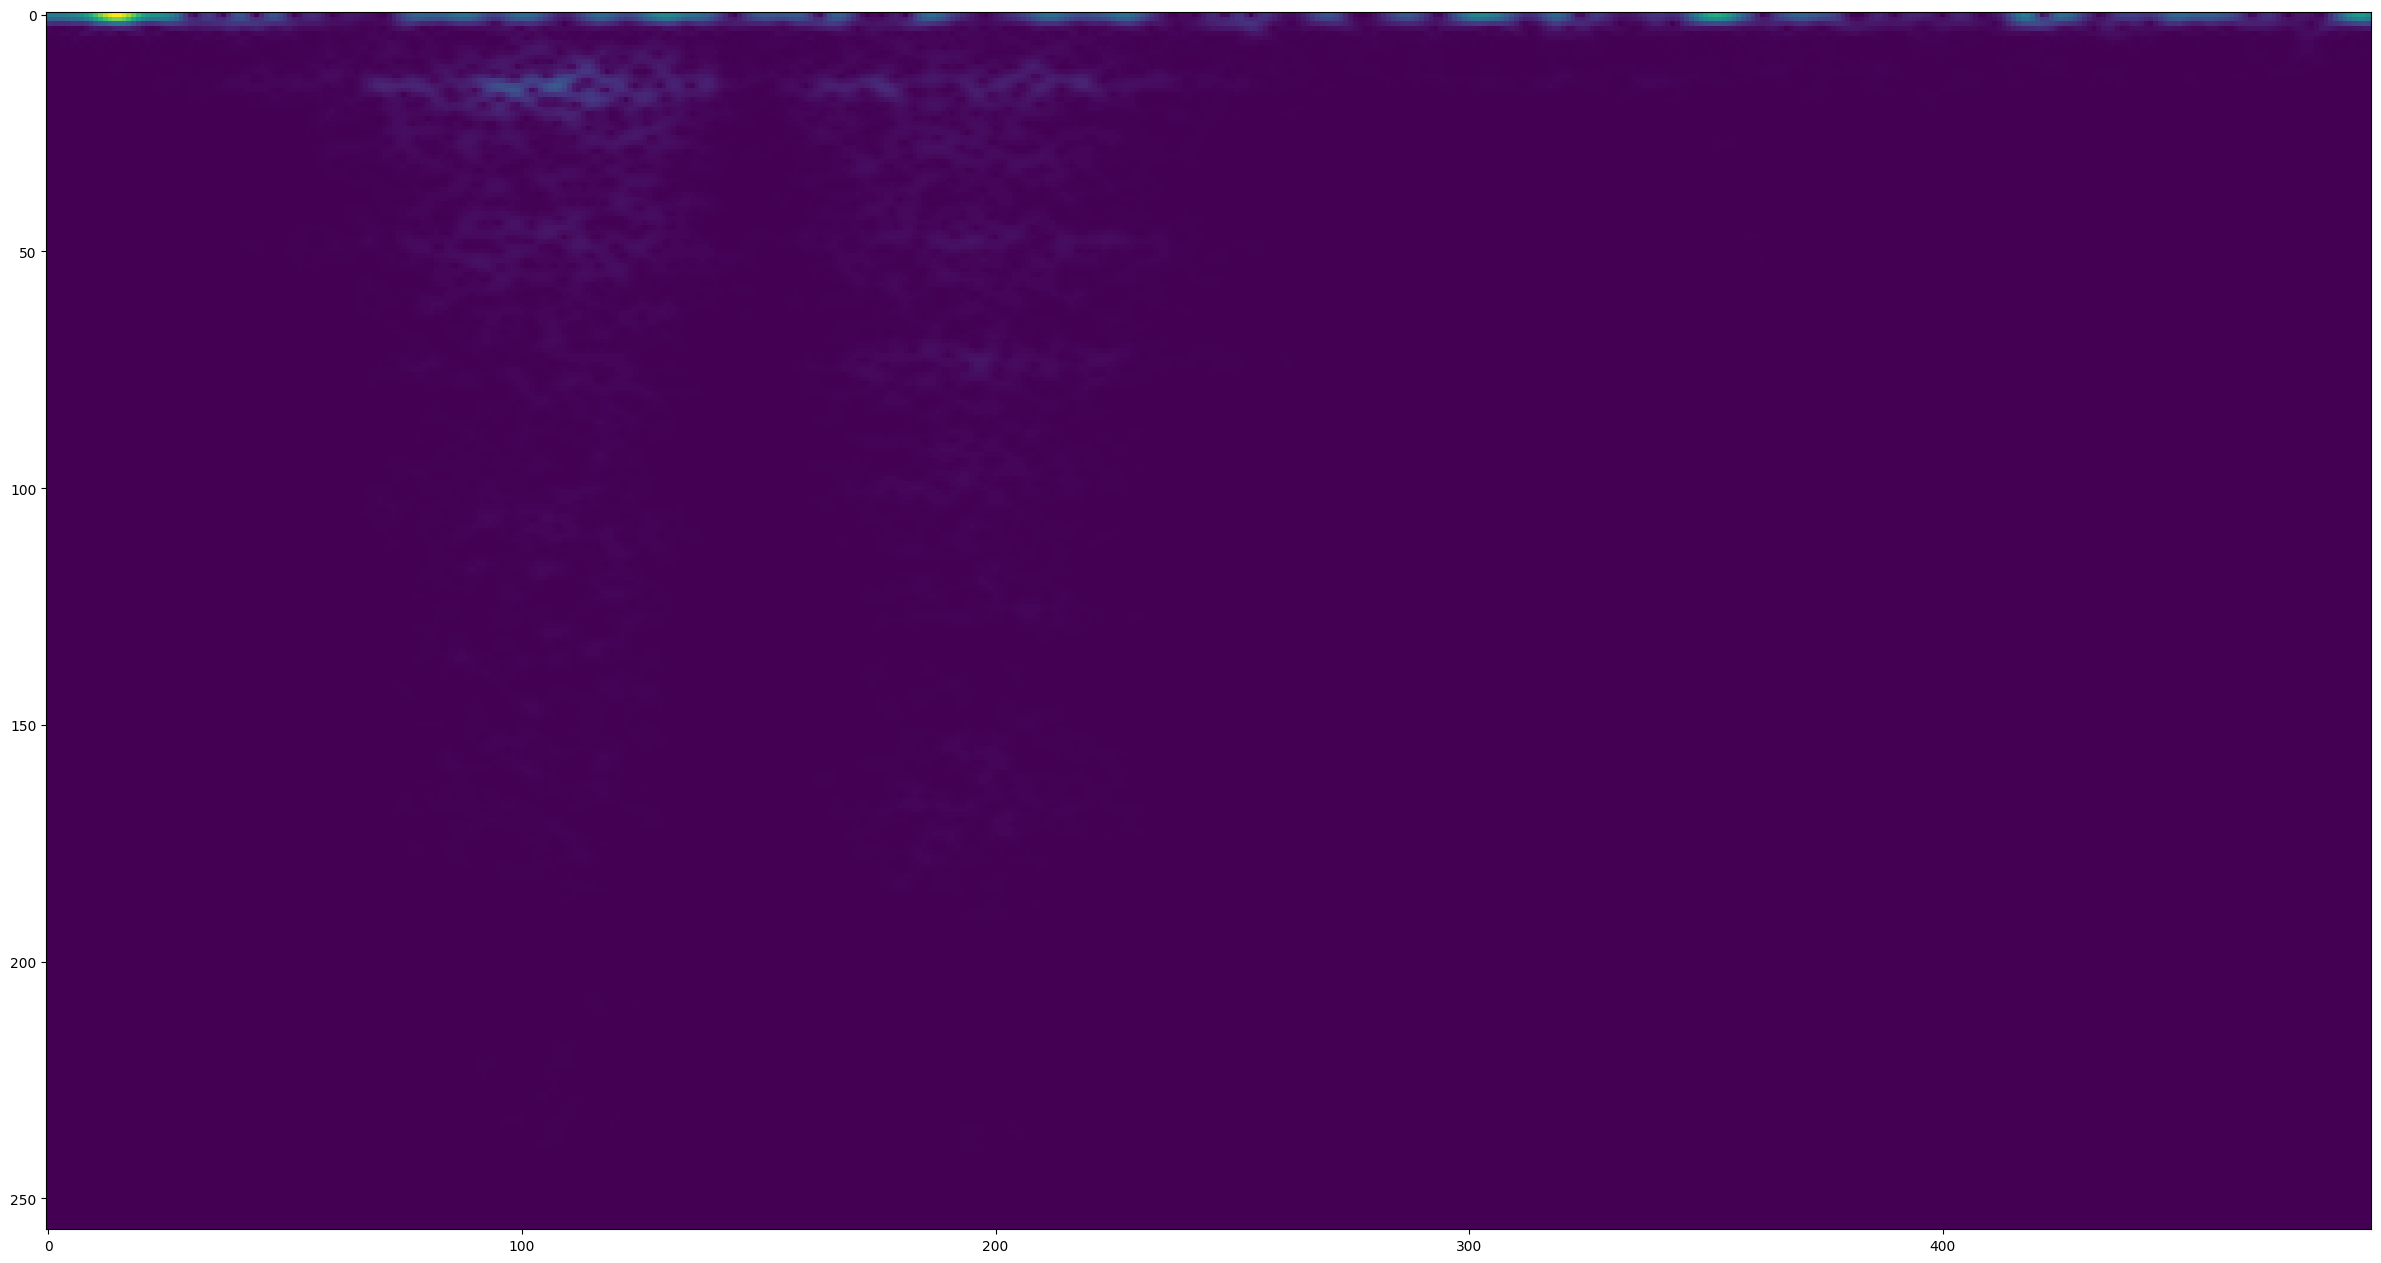

In [18]:
sample, label = nonsnoring_data.shuffle(buffer_size=1000).as_numpy_iterator().next()
spectrogram, label = preprocess(sample, label)
#print(spectrogram)
plt.figure(figsize=(30,20))
plt.imshow(tf.transpose(spectrogram)[0])
plt.show()

# Model Architecture

### DATA PIPELINE

In [19]:
## DATA PIPELINE
#  Puts all the data files through the pre-processing function to extract features,
# cache everything, shuffle everything, batch it, and pre-fetch to avoid bottleneck.

data = all_data.map(preprocess)
data = data.cache()
data = data.shuffle(buffer_size=1000)
data = data.batch(16)
data = data.prefetch(8)

In [20]:
## Test-Train Split

TRAIN_PERCENT = 0.7
train_amt = int(len(data) * TRAIN_PERCENT)
test_amt = int(len(data) - train_amt)


train = data.take(train_amt)
test = data.skip(train_amt).take(test_amt)

In [21]:
samples, labels = train.as_numpy_iterator().next()
samples.shape

(16, 491, 257, 1)

### MODEL ARCHITECTURE FOR REAL

In [22]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, Dense, Flatten, MaxPool2D, GlobalAveragePooling2D

In [23]:
INPUT_SHAPE = samples.shape[1:]

model = Sequential()
model.add(Conv2D(16, (3,3), activation='relu', input_shape=INPUT_SHAPE))
model.add(MaxPool2D())
model.add(Conv2D(16, (3,3), activation='relu'))
model.add(MaxPool2D())
model.add(Conv2D(16, (3,3), activation='relu'))
model.add(MaxPool2D())
model.add(Flatten())
#model.add(GlobalAveragePooling2D())
model.add(Dense(128, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

model.compile('Adam', loss='BinaryCrossentropy', metrics=[tf.keras.metrics.Recall(),tf.keras.metrics.Precision()])

model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 489, 255, 16)   │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 244, 127, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 242, 125, 16)   │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 121, 62, 16)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 119, 60, 16)    │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 59, 30, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 28320)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,625,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,630,017 (13.85 MB)

 Trainable params: 3,630,017 (13.85 MB)

 Non-trainable params: 0 (0.00 B)

In [24]:
hist = model.fit(train, epochs=4, validation_data=test)

Epoch 1/4
44/44 ━━━━━━━━━━━━━━━━━━━━ 10s 65ms/step - loss: 0.5558 - precision: 0.7927 - recall: 0.7345 - val_loss: 0.2579 - val_precision: 0.8767 - val_recall: 0.8889
Epoch 2/4
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.2618 - precision: 0.9020 - recall: 0.9020 - val_loss: 0.1842 - val_precision: 0.9079 - val_recall: 0.9650
Epoch 3/4
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.1708 - precision: 0.9379 - recall: 0.9405 - val_loss: 0.0980 - val_precision: 0.9484 - val_recall: 0.9866
Epoch 4/4
44/44 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - loss: 0.0941 - precision: 0.9529 - recall: 0.9801 - val_loss: 0.0578 - val_precision: 0.9664 - val_recall: 1.0000


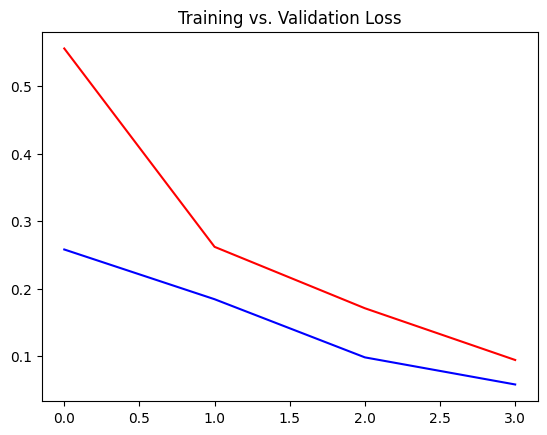

In [25]:
plt.title('Training vs. Validation Loss')
plt.plot(hist.history['loss'], 'red')
plt.plot(hist.history['val_loss'], 'blue')
plt.show()

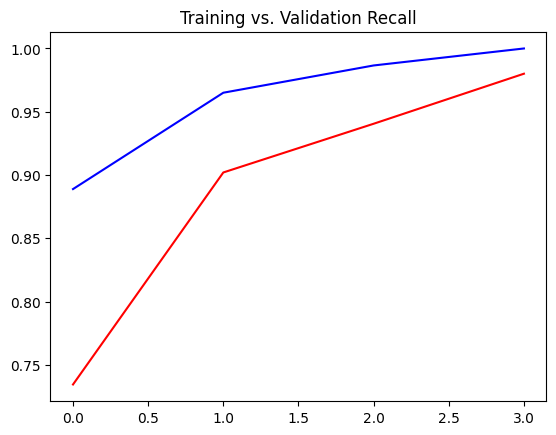

In [27]:
plt.title('Training vs. Validation Recall')
plt.plot(hist.history['recall'], 'red')
plt.plot(hist.history['val_recall'], 'blue')
plt.show()

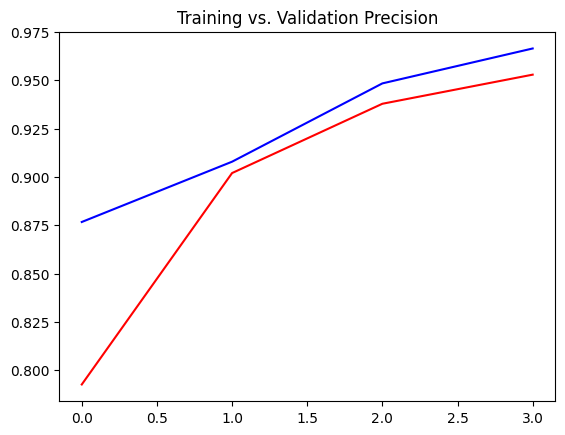

In [28]:
plt.title('Training vs. Validation Precision')
plt.plot(hist.history['precision'], 'red')
plt.plot(hist.history['val_precision'], 'blue')
plt.show()

In [29]:
x_text,  y_test = test.as_numpy_iterator().next()

y_pred = model.predict(x_text)
y_pred = [1 if prediction > 0.5 else 0 for prediction in y_pred]
print(f"Pred: {y_pred}\nReal: {y_test}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 321ms/step
Pred: [1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0]
Real: [1. 1. 0. 1. 0. 1. 1. 0. 0. 1. 1. 0. 0. 1. 0. 0.]


In [30]:
model.evaluate(test)

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0562 - precision: 0.9669 - recall: 0.9932


[0.056243717670440674, 0.9931972622871399, 0.9668874144554138]